# minGRU (Feng et al., 2024) with the associative scan
## This code uses `heinsen` associative scan instead of flax.linen.scan to further optimize the code


## Equations
State update:

$
\vec{z}_t = \sigma(W^{z}\vec{x}_t) \\
\vec{\~h}_t = W^{h}\vec{x}_t \\
\vec{h}_t = (1 - \vec{z}_t) \odot \vec{h}_{t-1} + \vec{z}_t \odot \vec{\~h}_t \\
$

Output: mean of output over time (or cummulative sum of output over time):

$
\vec{o}_t = W^{oh}\vec{h}_t + \vec{b}^o \\
\vec{o} = \frac{1}{T}\sum_{t=1}^{T}\vec{o}_t \\
\vec{y} = \text{softmax}(\vec{o}) \\
$

## Heinsen Associative Scan

$
\vec{h}_t = (1 - \vec{z}_t) \odot \vec{h}_{t-1} + \vec{z}_t \odot \vec{\~h}_t \\
$

Can be rewritten as:

$
\vec{h}_t = \vec{a}_t \odot \vec{h}_{t-1} + \vec{b}_t \text{ where } 
\vec{a}_t = 1 - \vec{z}_t \text{ and }
\vec{b}_t = \vec{z}_t \odot \vec{\~h}_t 
$

This can be speed up by using the formula:
$ \overrightarrow{h}_t = (\prod_{n=1}^{t,cum} a_n) \odot (x_0 + \sum_{n=1}^{t,cum} \frac{b_n}{\prod_{n=1}^{t} a_n}) $

However, this formula is numerically unstable because of the product of a large number of small values. To avoid this, we can use the log-sum-exp trick:

$ log(\overrightarrow{h}_t) = log(\prod_{n=1}^{t,cum} a_n) + log(x_0 + \sum_{n=1}^{t,cum} \frac{b_n}{\prod_{n=1}^{t} a_n}) $

$ log(\overrightarrow{h}_t) = \sum_{n=1}^{t,cum} log(a_n) + log(x_0 + \sum_{n=1}^{t,cum} \frac{b_n}{\prod_{n=1}^{t} a_n}) $



In [1]:
!pwd
!which python
!pip freeze | grep -E 'flax|jax|orbax|optax'

/home/christian/LearningJAX/Flax
/home/christian/miniconda3/envs/.jax_conda_env_DPP/bin/python
flax==0.10.4
jax==0.5.3
jax-cuda12-pjrt==0.5.3
jax-cuda12-plugin==0.5.3
jaxlib==0.5.3
optax==0.1.8
orbax-checkpoint==0.5.0


In [2]:
import jax
import numpy as np
import torch
from jax import numpy as jnp
from torch.utils.data import TensorDataset
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
from flax import linen as nn
from flax.training import train_state, checkpoints
import optax
from jax.nn.initializers import lecun_normal
from typing import Any, Tuple, Sequence, Optional
import matplotlib.pyplot as plt
px = 1 / plt.rcParams['figure.dpi']

jnp.set_printoptions(precision=3, suppress=True)

# set cuda visible devices
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
# set jax XLA_PYTHON_CLIENT_MEM_FRACTION=.XX
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".95"

# fix random seed
key = jax.random.PRNGKey(0)
torch.manual_seed(0)
np.random.seed(0)


In [3]:
from utils import create_mnist_classification_dataset, plot_dynamics

In [4]:
TIMEDECAY_MEAN = 30.0, 5.0
DECAY = True

DATASET_VERSION = 'sequential'
HIDDEN_DIM = 64 #2*x*(1+x*(n-1)+n+5+10/x)
BATCH_SIZE = 128
N_LAYERS = 2
N_EPOCHS = 50
LR = 1e-3
REG_FACTOR = 1e-8 # 1e-6, 1e-7, 1e-8, 1e-9, 0.0

key, subkey = jax.random.split(key)
trainloader, val_loader, testloader, N_CLASSES, SEQ_LENGTH, IN_DIM = create_mnist_classification_dataset(bsz=BATCH_SIZE, root="../data", version=DATASET_VERSION)

[*] Generating MNIST Classification Dataset...


In [5]:
batch_x, batch_y = next(iter(testloader))
print(batch_x.shape, batch_y.shape)
print(batch_y.dtype)

(128, 784, 1) (128,)
int64


In [6]:
def bimodal_gaussian(key, size, mean1, mean2, std1, std2, weight1=0.5):
    """
    Draw samples from a bimodal Gaussian distribution.
    
    Args:
        key: JAX random key.
        size: Number of samples to draw.
        mean1: Mean of the first Gaussian.
        mean2: Mean of the second Gaussian.
        std1: Standard deviation of the first Gaussian.
        std2: Standard deviation of the second Gaussian.
        weight1: Weight of the first Gaussian (between 0 and 1).
                 The second Gaussian will have weight (1 - weight1).
    
    Returns:
        Samples from the bimodal Gaussian distribution.
    """
    # Split the random key
    key1, key2 = jax.random.split(key)
    
    # Draw samples from two Gaussian distributions
    samples1 = jax.random.normal(key1, shape=size) * std1 + mean1
    samples2 = jax.random.normal(key2, shape=size) * std2 + mean2
    
    # Randomly choose between the two distributions based on the weights
    mix_key = jax.random.uniform(key, shape=size)
    mask = mix_key < weight1  # True for samples from the first Gaussian
    
    # Combine the samples
    samples = jnp.where(mask, samples1, samples2)
    return samples

In [7]:
from typing import Sequence

def identity_weight_init():
    def init(key, shape, dtype=jnp.float32):
        w = jnp.eye(shape[0], shape[1], dtype=dtype) * 0.9
        w = w.at[-1, :].set(1.0)
        return w
    return init

class minGRULayer(nn.Module):
    '''
    MGU Layer
    We use a modified version of the h_tilde calculation in the MGU cell for better performance.
    - $f_t = \sigma(W^{fx} x_t + U^{fh} h_{t-1} + b^f)$
    - $\~{h}_t = \tanh(W^{hx} x_t + f_t \odot (U^{hh} h_{t-1} + b^h))$
    
    Args:
        hidden_size: int, size of hidden state
        output_size: int, size of output
    '''
    hidden_size: int
    output_size: int

    @nn.compact
    def __call__(self, x):

        def update(self, state, x):
            h = state[0]
            z_htilde = nn.Dense(2*self.hidden_size, name='Dense_x')(x)
            z_preact, h_tilde = jnp.split(z_htilde, 2, axis=-1)
            z = nn.sigmoid(z_preact)
            h_new = (1 - z) * h + z * h_tilde
            return (h_new,), (h_new, z, z_preact)

        scan_update = nn.scan(
            update,
            variable_broadcast='params',
            split_rngs={'params': False},
            in_axes=0,
            out_axes=0,
        )
        h = jnp.zeros((self.hidden_size,))
        state = (h,)
        _, state_hist = scan_update(self, state, x)

        return state_hist


class HeinsenMinGRULayer(nn.Module):
    '''
    MGU Layer
    We use a modified version of the h_tilde calculation in the MGU cell for better performance.
    - $f_t = \sigma(W^{fx} x_t + U^{fh} h_{t-1} + b^f)$
    - $\~{h}_t = \tanh(W^{hx} x_t + f_t \odot (U^{hh} h_{t-1} + b^h))$
    
    Args:
        hidden_size: int, size of hidden state
        output_size: int, size of output
    '''
    hidden_size: int
    output_size: int
    decay: bool
    timedecay_mean: Sequence[float]


    @nn.compact
    def __call__(self, x):


        def softplus(x):
            return jnp.log(1 + jnp.exp(x))
        def safe_softplus(x):
            x_safe = jnp.where(x > 10, 0, x)
            return jnp.where(x > 10, x, softplus(x_safe))
        def log_g(x):
            x_safe = jnp.where(x == -0.5, x+1e-5, x)
            return jnp.where(x >= 0, jnp.log(x_safe+0.5), -safe_softplus(-x))        
        
        def exponential_decay_kernel(time_constants, length):
            """
            Generate an exponential decay kernel for each time constant.
            Args:
                time_constants: Array of time constants (shape: [hidden_size]).
                length: Length of the kernel.
            Returns:
                A kernel matrix of shape [hidden_size, length].
            """
            t = jnp.arange(length)
            kernel = jnp.exp(-t[:, None] / time_constants[None, :])
            return kernel.T  # Shape: [hidden_size, length]


        def heinsen_update(z, h):
            '''
            we can formulate h_{t} = (1 - z_t) * h_{t-1} + z_t * h_tilde_t as 
            h_t = a_t * h_{t-1} + b_t with a_t = 1 - z_t and b_t = z_t * h_tilde_t which can be precomputed
            '''
            x_0 = -10000.
            log_a = -safe_softplus(z)
            log_b = -safe_softplus(-z) + log_g(h)
            a_star = jnp.cumsum(log_a)

            c = log_b - a_star 
            c = jnp.pad(c, (1, 0), constant_values=x_0)
            d = jax.lax.cumlogsumexp(c)
            d = d[1:] # tailing d
            log_final = a_star + d
            return jnp.exp(log_final)
        
        vj_heinsen_update = jax.vmap(jax.jit(heinsen_update), in_axes=(1, 1), out_axes=1)

        # Define trainable time constants
        lower_bound = 1.0 #mean * 0.5
        upper_bound = self.timedecay_mean[0] * 1.5

        
        # time_constants = self.param(
        #     'time_constants',
        #     lambda rng, shape: bimodal_gaussian(rng, shape, TIMEDECAY_MEAN[0], TIMEDECAY_MEAN[1], 2/3*TIMEDECAY_MEAN[0], 2/3*TIMEDECAY_MEAN[1], weight1=0.5),
        #     (self.hidden_size,)
        # )
        # time_constants_2 = self.param(
        #     'time_constants_2',
        #     lambda rng, shape: bimodal_gaussian(rng, shape, mean, 5.0, 20.0, 4.0, weight1=0.5),
        #     (self.hidden_size,)
        # )
        key = jax.random.key(1)
        time_constants = bimodal_gaussian(key, (self.hidden_size,), self.timedecay_mean[0], self.timedecay_mean[1], 2/3*self.timedecay_mean[0], 2/3*self.timedecay_mean[1], weight1=0.5)
        # key = jax.random.key(2)
        # time_constants_2 = bimodal_gaussian(key, (self.hidden_size,),TIMEDECAY_MEAN[0], TIMEDECAY_MEAN[1], 2/3*TIMEDECAY_MEAN[0], 2/3*TIMEDECAY_MEAN[1] weight1=0.5)

        # time_constants = jax.random.normal(key, (self.hidden_size,)) * 20.0 + mean
        time_constants = jnp.clip(jnp.abs(time_constants), lower_bound, upper_bound)
        # time_constants_2 = jnp.clip(jnp.abs(time_constants_2), lower_bound, upper_bound)

        # Ensure time constants are positive
        time_constants = jax.nn.softplus(time_constants)
        # time_constants_2 = jax.nn.softplus(time_constants_2)

        # Generate decay kernels
        decay_kernels = exponential_decay_kernel(time_constants, 50)
        # decay_kernels_2 = exponential_decay_kernel(time_constants_2, 50)

        def update(x):
            '''
            As the x is not scanned anymore, x is 2D array (n_ts, n_features)
            - for sMNIST, the first layer will have x of shape (784, 1)

            '''
            z_htilde = nn.Dense(2*self.hidden_size, name='Dense_x')(x) # z_htilde: (784, 128)
            z_preact, h_tilde_preact = jnp.split(z_htilde, 2, axis=-1) # z_preact and h_tilde_preact: (784, 64)
            
            # Convolve h_tilde_preact with decay kernels
            # h_tilde_preact = jax.vmap(
            #     lambda h, k: jax.scipy.signal.convolve(h, k, mode='same'),
            #     in_axes=(1, 0), out_axes=1
            # )(h_tilde_preact, decay_kernels)
            #Convolve z_preact with decay kernels
            if self.decay:
                z_preact = jax.vmap(
                    lambda z_, k: jax.scipy.signal.convolve(z_, k, mode='same'),
                    in_axes=(1, 0), out_axes=1
                )(z_preact, decay_kernels)

            h_new = vj_heinsen_update(z_preact, h_tilde_preact) # h_new: (784, 64)
            return (h_new, z_preact, h_tilde_preact)
        
        state_hist = update(x)
        return state_hist

class RNNBackbone(nn.Module):
    hidden_size: int
    output_size: int
    n_layers: int
    decay: bool
    timedecay_mean: Sequence[float]
    recurrent_layer: nn.Module = HeinsenMinGRULayer


    @nn.compact
    def __call__(self, x):
        state_hist = []
        for _ in range(self.n_layers-1):
            x = self.recurrent_layer(self.hidden_size, self.output_size, self.decay, self.timedecay_mean)(x)
            state_hist.append(x)
            x = x[0]
        x = self.recurrent_layer(self.hidden_size, self.output_size, self.decay, self.timedecay_mean)(x)
        state_hist.append(x)
        out = nn.Dense(self.output_size, name='Dense_Out')(x[0])
        return state_hist, out
    
BatchRNN = nn.vmap(RNNBackbone, in_axes=0, out_axes=0, variable_axes={'params': None}, split_rngs={'params': False})


class RNNBackboneFirstLayer(nn.Module):
    hidden_size: int
    output_size: int
    n_layers: int
    decay: bool
    timedecay_mean: Sequence[float]
    recurrent_layer: nn.Module = HeinsenMinGRULayer

    @nn.compact
    def __call__(self, x):
        state_hist = []
        for l in range(self.n_layers-1):
            if l == 0:
                decay_param = True
            x = self.recurrent_layer(self.hidden_size, self.output_size, decay_param, self.timedecay_mean)(x)
            state_hist.append(x)
            x = x[0]
        x = self.recurrent_layer(self.hidden_size, self.output_size, False, self.timedecay_mean)(x)
        state_hist.append(x)
        out = nn.Dense(self.output_size, name='Dense_Out')(x[0])
        return state_hist, out
    
BatchRNNFirstLayer = nn.vmap(RNNBackboneFirstLayer, in_axes=0, out_axes=0, variable_axes={'params': None}, split_rngs={'params': False})


<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3054386/1863344397.py:11: SyntaxWarning: invalid escape sequence '\s'
  '''
/tmp/ipykernel_3054386/1863344397.py:50: SyntaxWarning: invalid escape sequence '\s'
  '''


In [8]:
@jax.jit
def update_model(state, grads):
    return state.apply_gradients(grads=grads)

In [9]:
from functools import partial

@partial(jax.jit, static_argnames=('reg_factor',))
def apply_model(state, x, y, reg_factor):
    """Computes gradients, loss and accuracy for a single batch."""

    def loss_fn(params):
        net_dyn, out_hist = state.apply_fn({'params': params}, x)
        logits = out_hist.mean(axis=1)
        one_hot = jax.nn.one_hot(y, 10)
        batch_loss = optax.softmax_cross_entropy(logits=logits, labels=one_hot)
        reg = 0.0
        for layers in net_dyn:
            reg += jnp.where(jnp.abs(layers[2]) > 1, layers[2]**2, 0.0).sum()
        reg += jnp.where(jnp.abs(out_hist) > 1, out_hist**2, 0.0).sum()
        loss = jnp.mean(batch_loss) + reg_factor * reg
        return loss, {'logits': logits, 'batch_loss': batch_loss, 'net_dyn': net_dyn}

    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
    (loss, aux_dict), grads = grad_fn(state.params)
    accuracy = jnp.mean(jnp.argmax(aux_dict['logits'], -1) == y)
    aux_dict.pop('logits')
    return grads, loss, accuracy, aux_dict
    

In [10]:
def map_nested_fn(fn):
    """Recursively apply `fn to the key-value pairs of a nested dict / pytree."""

    def map_fn(nested_dict):
        return {
            k: (map_fn(v) if hasattr(v, "keys") else fn(k, v))
            for k, v in nested_dict.items()
        }

    return map_fn

def run_epoch(state, train_dl, rng, reg_factor, lim_batch=None, keys_to_track=None, inner_keys_to_track=None):
    """Train for a single epoch."""

    epoch_loss = []
    epoch_accuracy = []
    progress_bar = tqdm(train_dl, desc="Training", leave=True)
    aux_dict_hist = {k: [] for k in keys_to_track+inner_keys_to_track}
    batch_id = 0
    break_flag = False
    for batch_x, batch_y in progress_bar:
        grads, loss, accuracy, aux_dict = apply_model(state, batch_x, batch_y, reg_factor=reg_factor)
        
        for k in keys_to_track:
            aux_dict_hist[k].append(locals()[k])
        for k in inner_keys_to_track:
            aux_dict_hist[k].append(aux_dict[k])

        epoch_loss.append(loss)
        epoch_accuracy.append(accuracy)
        
        if jnp.isnan(loss).sum() > 0:
            print('NAN Loss')
            break_flag = True
            break

        state = update_model(state, grads)
        batch_id += 1

        if batch_id % 3 == 0:
            progress_bar.set_postfix(loss=loss.item(), accuracy=accuracy.item())       

        if lim_batch is not None and batch_id >= lim_batch:
            break_flag = True
            break 
        
    train_loss = np.mean(epoch_loss)
    train_accuracy = np.mean(epoch_accuracy)
    return state, train_loss, train_accuracy, (break_flag, aux_dict_hist)


In [11]:
@jax.jit
def eval_model(state, images, labels):
    """Computes gradients, loss and accuracy for a single batch."""

    def loss_fn(params):
        _, out_hist = state.apply_fn({'params': params}, images)
        logits = out_hist.mean(axis=1)
        one_hot = jax.nn.one_hot(labels, 10)
        loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
        return loss, logits

    loss, logits = loss_fn(state.params)
    accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
    return loss, accuracy

In [12]:
def validate(state, testloader):
    # Compute average loss & accuracy
    # model = model(training=False) # needed when using dropout
    losses, accuracies = [], []
    for batch_idx, (inputs, labels) in enumerate(testloader):
        loss, acc = eval_model(
            state, inputs, labels # from S4D: , model, classification=classification
        )
        losses.append(loss)
        accuracies.append(acc)
    return np.mean(losses), np.mean(accuracies)


In [13]:


def create_train_state(key, model_cls, lr, dataset_version, hidden_size, n_layers, batch_size, decay, timedecay_mean):
    
    init_x = jnp.ones((batch_size, 784, 1)) if dataset_version == "sequential" else jnp.ones((batch_size, 28, 28))

    model = model_cls(hidden_size=hidden_size, output_size=10, n_layers=n_layers, decay=decay, timedecay_mean=timedecay_mean)
    params = model.init(key, init_x)['params']
    
    # Debugging: Print parameter structure
    print("Initialized parameter structure:", jax.tree_util.tree_map(jnp.shape, params))

    param_sizes = map_nested_fn(
        lambda k, param: param.size
        # if lr_layer.get(k, lr) > 0.0
        # else 0
    )(params)
    print(f"[*] Trainable Parameters: {sum(jax.tree_util.tree_leaves(param_sizes))}")

    optimizer = optax.chain(
        # optax.clip_by_global_norm(1.0),
        optax.adamw(lr, weight_decay=1e-2),
    )
    return train_state.TrainState.create(
        apply_fn=model.apply,
        params=params,
        tx=optimizer,
    )

# Multi Layer (3 hidden, 1 output) 
## This code uses flax.linen.scan to speed up the loop over time

## Equations
The output of a LSTM layer is $

In [14]:
#model = BatchRNN(hidden_size=HIDDEN_DIM, output_size=10, n_layers=N_LAYERS, decay=DECAY, timedecay_mean=TIMEDECAY_MEAN)
model = BatchRNNFirstLayer(hidden_size=HIDDEN_DIM, output_size=10, n_layers=N_LAYERS, decay=DECAY, timedecay_mean=TIMEDECAY_MEAN)
# model_mingru = BatchRNN(HIDDEN_DIM, 10, N_LAYERS, recurrent_layer=minGRULayer)
state = create_train_state(key, BatchRNN, LR, DATASET_VERSION, HIDDEN_DIM, N_LAYERS, BATCH_SIZE, DECAY, TIMEDECAY_MEAN)

Initialized parameter structure: {'Dense_Out': {'bias': (10,), 'kernel': (64, 10)}, 'HeinsenMinGRULayer_0': {'Dense_x': {'bias': (128,), 'kernel': (1, 128)}}, 'HeinsenMinGRULayer_1': {'Dense_x': {'bias': (128,), 'kernel': (64, 128)}}}
[*] Trainable Parameters: 9226


In [15]:
params = model.init(jax.random.PRNGKey(0), jnp.zeros_like(batch_x[:BATCH_SIZE]))
# params_mingru = model_mingru.init(jax.random.PRNGKey(0), jnp.zeros_like(batch_x[:BATCH_SIZE]))

In [16]:
print(jax.tree_util.tree_map(jnp.shape, params['params']))
# print(jax.tree_util.tree_map(jnp.shape, params_mingru['params']))

{'Dense_Out': {'bias': (10,), 'kernel': (64, 10)}, 'HeinsenMinGRULayer_0': {'Dense_x': {'bias': (128,), 'kernel': (1, 128)}}, 'HeinsenMinGRULayer_1': {'Dense_x': {'bias': (128,), 'kernel': (64, 128)}}}


2
3
(5, 784, 64)


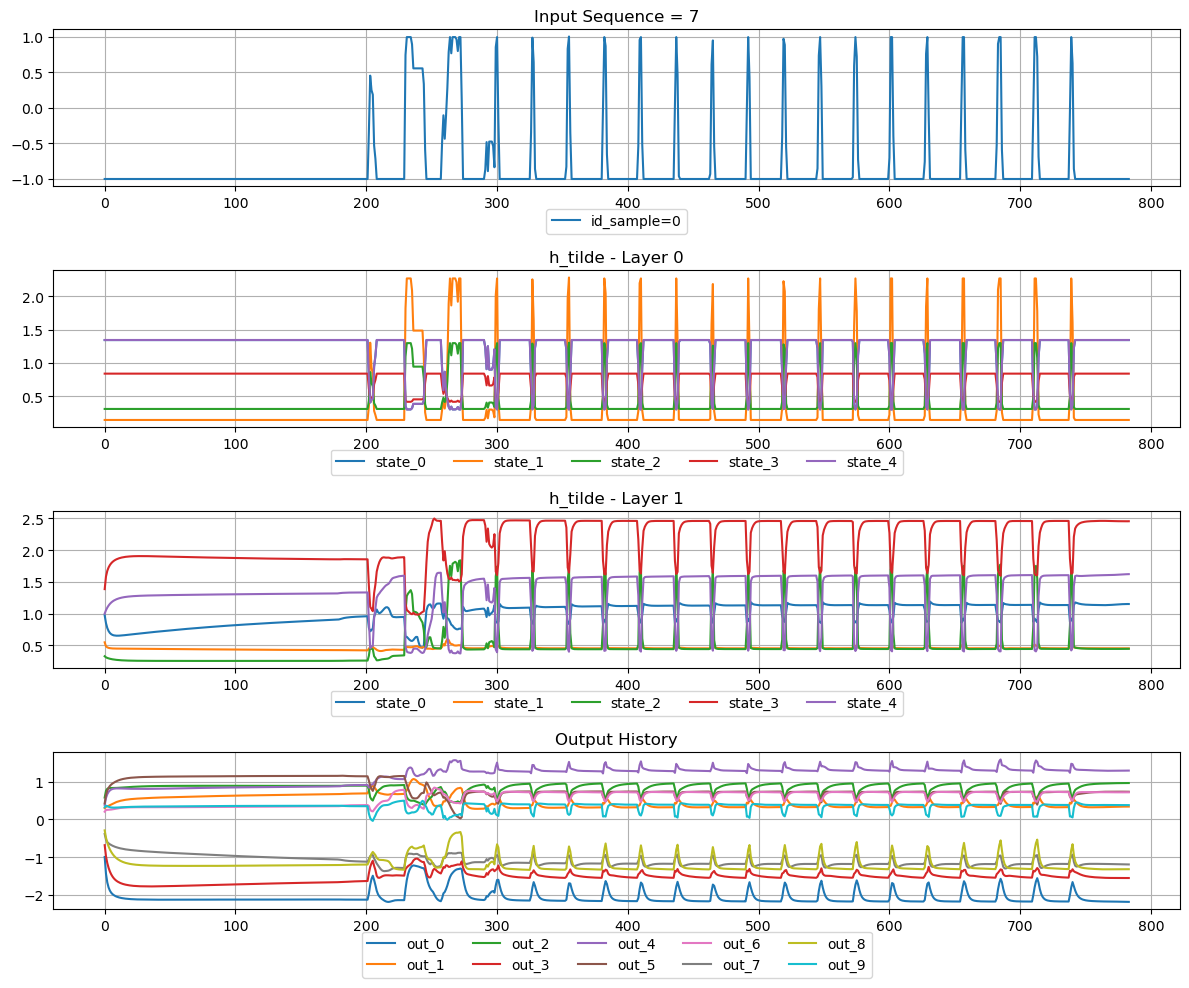

In [17]:
plot_dynamics(model, state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='h_tilde')

2
3
(5, 784, 64)


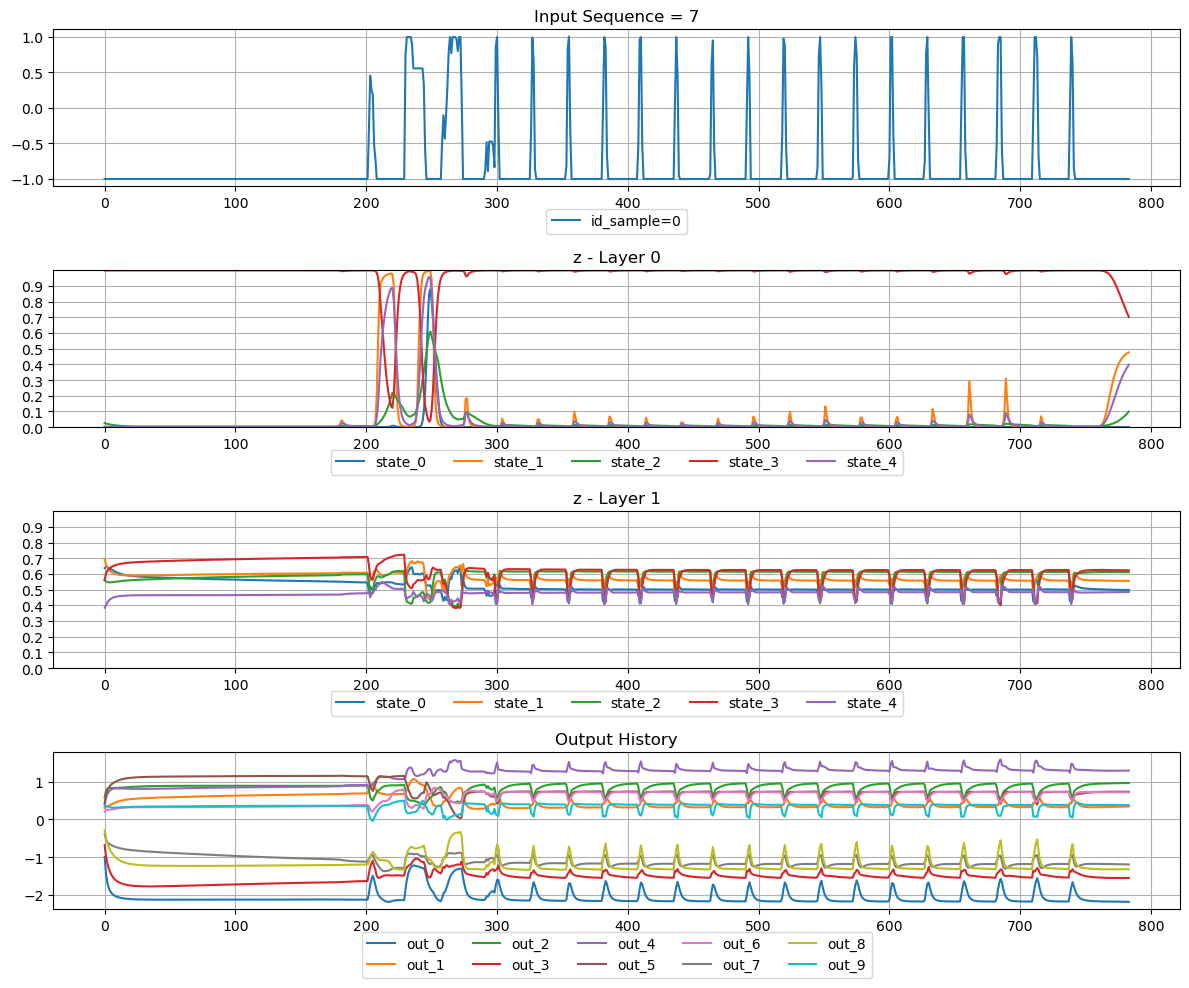

In [18]:
plot_dynamics(model, state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='z')

In [19]:
N_EPOCHS = 50
reg_factor = 0.0 #REG_FACTOR # 1e-8 # 1e-6, 1e-7, 1e-8, 1e-9, 0.0
id_sim = f"mingru_heinsen/{DATASET_VERSION}_h{HIDDEN_DIM}_l{N_LAYERS}_lr{LR}_bsz{BATCH_SIZE}_reg{reg_factor}"
CKPT_DIR = os.path.join(os.getcwd(), f"checkpoints/{id_sim}")
print(CKPT_DIR)
RESULT_DIR = os.path.join(os.getcwd(), f"results/{id_sim}")
print(RESULT_DIR)
os.makedirs(RESULT_DIR, exist_ok=True)
PLT_DIR = os.path.join(os.getcwd(), f"plots/{id_sim}")
print(PLT_DIR)
os.makedirs(PLT_DIR, exist_ok=True)


train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
# 'batch_loss' = [loss_sample1, loss_sample2, ..., loss_sampleBS]
# 'loss' = [loss_batch1, loss_batch2, ..., loss_batchN] where N is the number of batches and loss_batchX = mean([loss_sample1, loss_sample2, ..., loss_sampleBS])
keys_to_track = ['grads', 'loss', 'state'] #['grads', 'loss', 'state', 'batch_x', 'batch_y'] # ['batch_x', 'batch_y', 'state', 'grads']
inner_keys_to_track = [] #['batch_loss', 'net_dyn']
aux_dict_training = []

best_val_acc = 0.0
improvement = 0.01 # 1%, minimum improvement to save checkpoint

async_manager = checkpoints.AsyncManager()

for epoch in range(N_EPOCHS):
    key, subkey = jax.random.split(key) # not used in run_epoch (TODO: remove?)
    state, train_loss, train_accuracy, (break_flag, aux_dict_epoch) = run_epoch(state, trainloader, key, reg_factor=reg_factor, lim_batch=None, keys_to_track=keys_to_track, inner_keys_to_track=inner_keys_to_track)
    aux_dict_training.append(aux_dict_epoch)
    if break_flag:
        break
    val_loss, val_acc  = validate(state, val_loader)
    if val_acc > best_val_acc + improvement:
        best_val_acc = val_acc
        if best_val_acc > 0.97: improvement = 0.001 # 0.1%
        checkpoints.save_checkpoint(ckpt_dir=CKPT_DIR, target=state, step=state.step, overwrite=True, async_manager=async_manager)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_accuracy*100:.2f}% | val_loss: {val_loss:.4f} | val_acc: {val_acc*100:.2f}%")


test_loss, test_acc  = validate(state, testloader)
print(f"Final Test | test_loss: {test_loss:.4f} | test_acc: {test_acc*100:.2f}%")

# Save training dynamics
np.savez(os.path.join(RESULT_DIR, 'training_dynamics.npz'), 
         train_losses=train_losses, 
         train_accuracies=train_accuracies, 
         val_losses=val_losses, 
         val_accuracies=val_accuracies)

/home/christian/LearningJAX/Flax/checkpoints/mingru_heinsen/sequential_h64_l2_lr0.001_bsz128_reg0.0
/home/christian/LearningJAX/Flax/results/mingru_heinsen/sequential_h64_l2_lr0.001_bsz128_reg0.0
/home/christian/LearningJAX/Flax/plots/mingru_heinsen/sequential_h64_l2_lr0.001_bsz128_reg0.0


Training:   0%|          | 0/390 [00:00<?, ?it/s]

Training: 100%|██████████| 390/390 [00:16<00:00, 23.12it/s, accuracy=0.664, loss=1.32]


Epoch 0 | train_loss: 1.7773 | train_acc: 40.02% | val_loss: 1.3519 | val_acc: 58.03%


Training: 100%|██████████| 390/390 [00:09<00:00, 42.79it/s, accuracy=0.719, loss=0.954]


...

Epoch 47 | train_loss: 0.2261 | train_acc: 92.93% | val_loss: 0.2455 | val_acc: 92.53%


Training: 100%|██████████| 390/390 [00:09<00:00, 42.93it/s, accuracy=0.906, loss=0.242]


Epoch 48 | train_loss: 0.2183 | train_acc: 93.14% | val_loss: 0.2352 | val_acc: 92.80%


Training: 100%|██████████| 390/390 [00:09<00:00, 42.90it/s, accuracy=0.945, loss=0.146]


Epoch 49 | train_loss: 0.2202 | train_acc: 93.08% | val_loss: 0.2357 | val_acc: 92.52%
Final Test | test_loss: 0.2239 | test_acc: 92.93%


In [20]:
print(jax.tree_util.tree_map(jnp.shape, params['params']))

{'Dense_Out': {'bias': (10,), 'kernel': (64, 10)}, 'HeinsenMinGRULayer_0': {'Dense_x': {'bias': (128,), 'kernel': (1, 128)}}, 'HeinsenMinGRULayer_1': {'Dense_x': {'bias': (128,), 'kernel': (64, 128)}}}


/home/christian/LearningJAX/Flax/utils.py:377: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


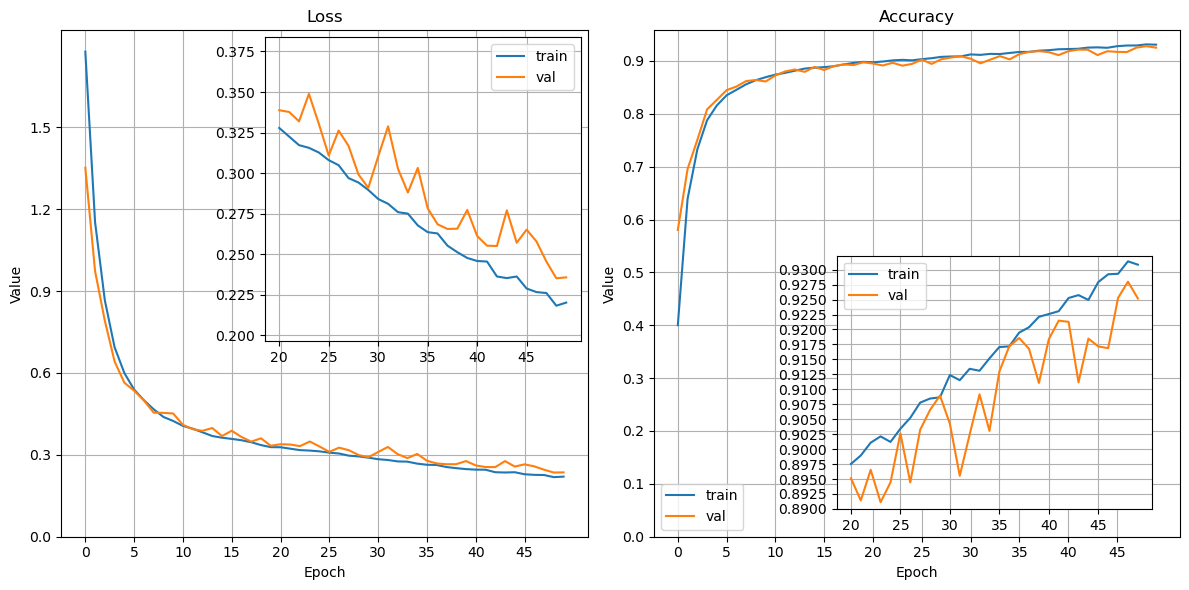

In [21]:
from utils import plot_loss_and_acc
plot_loss_and_acc(train_losses, val_losses, train_accuracies, val_accuracies)

(9, 784, 10)


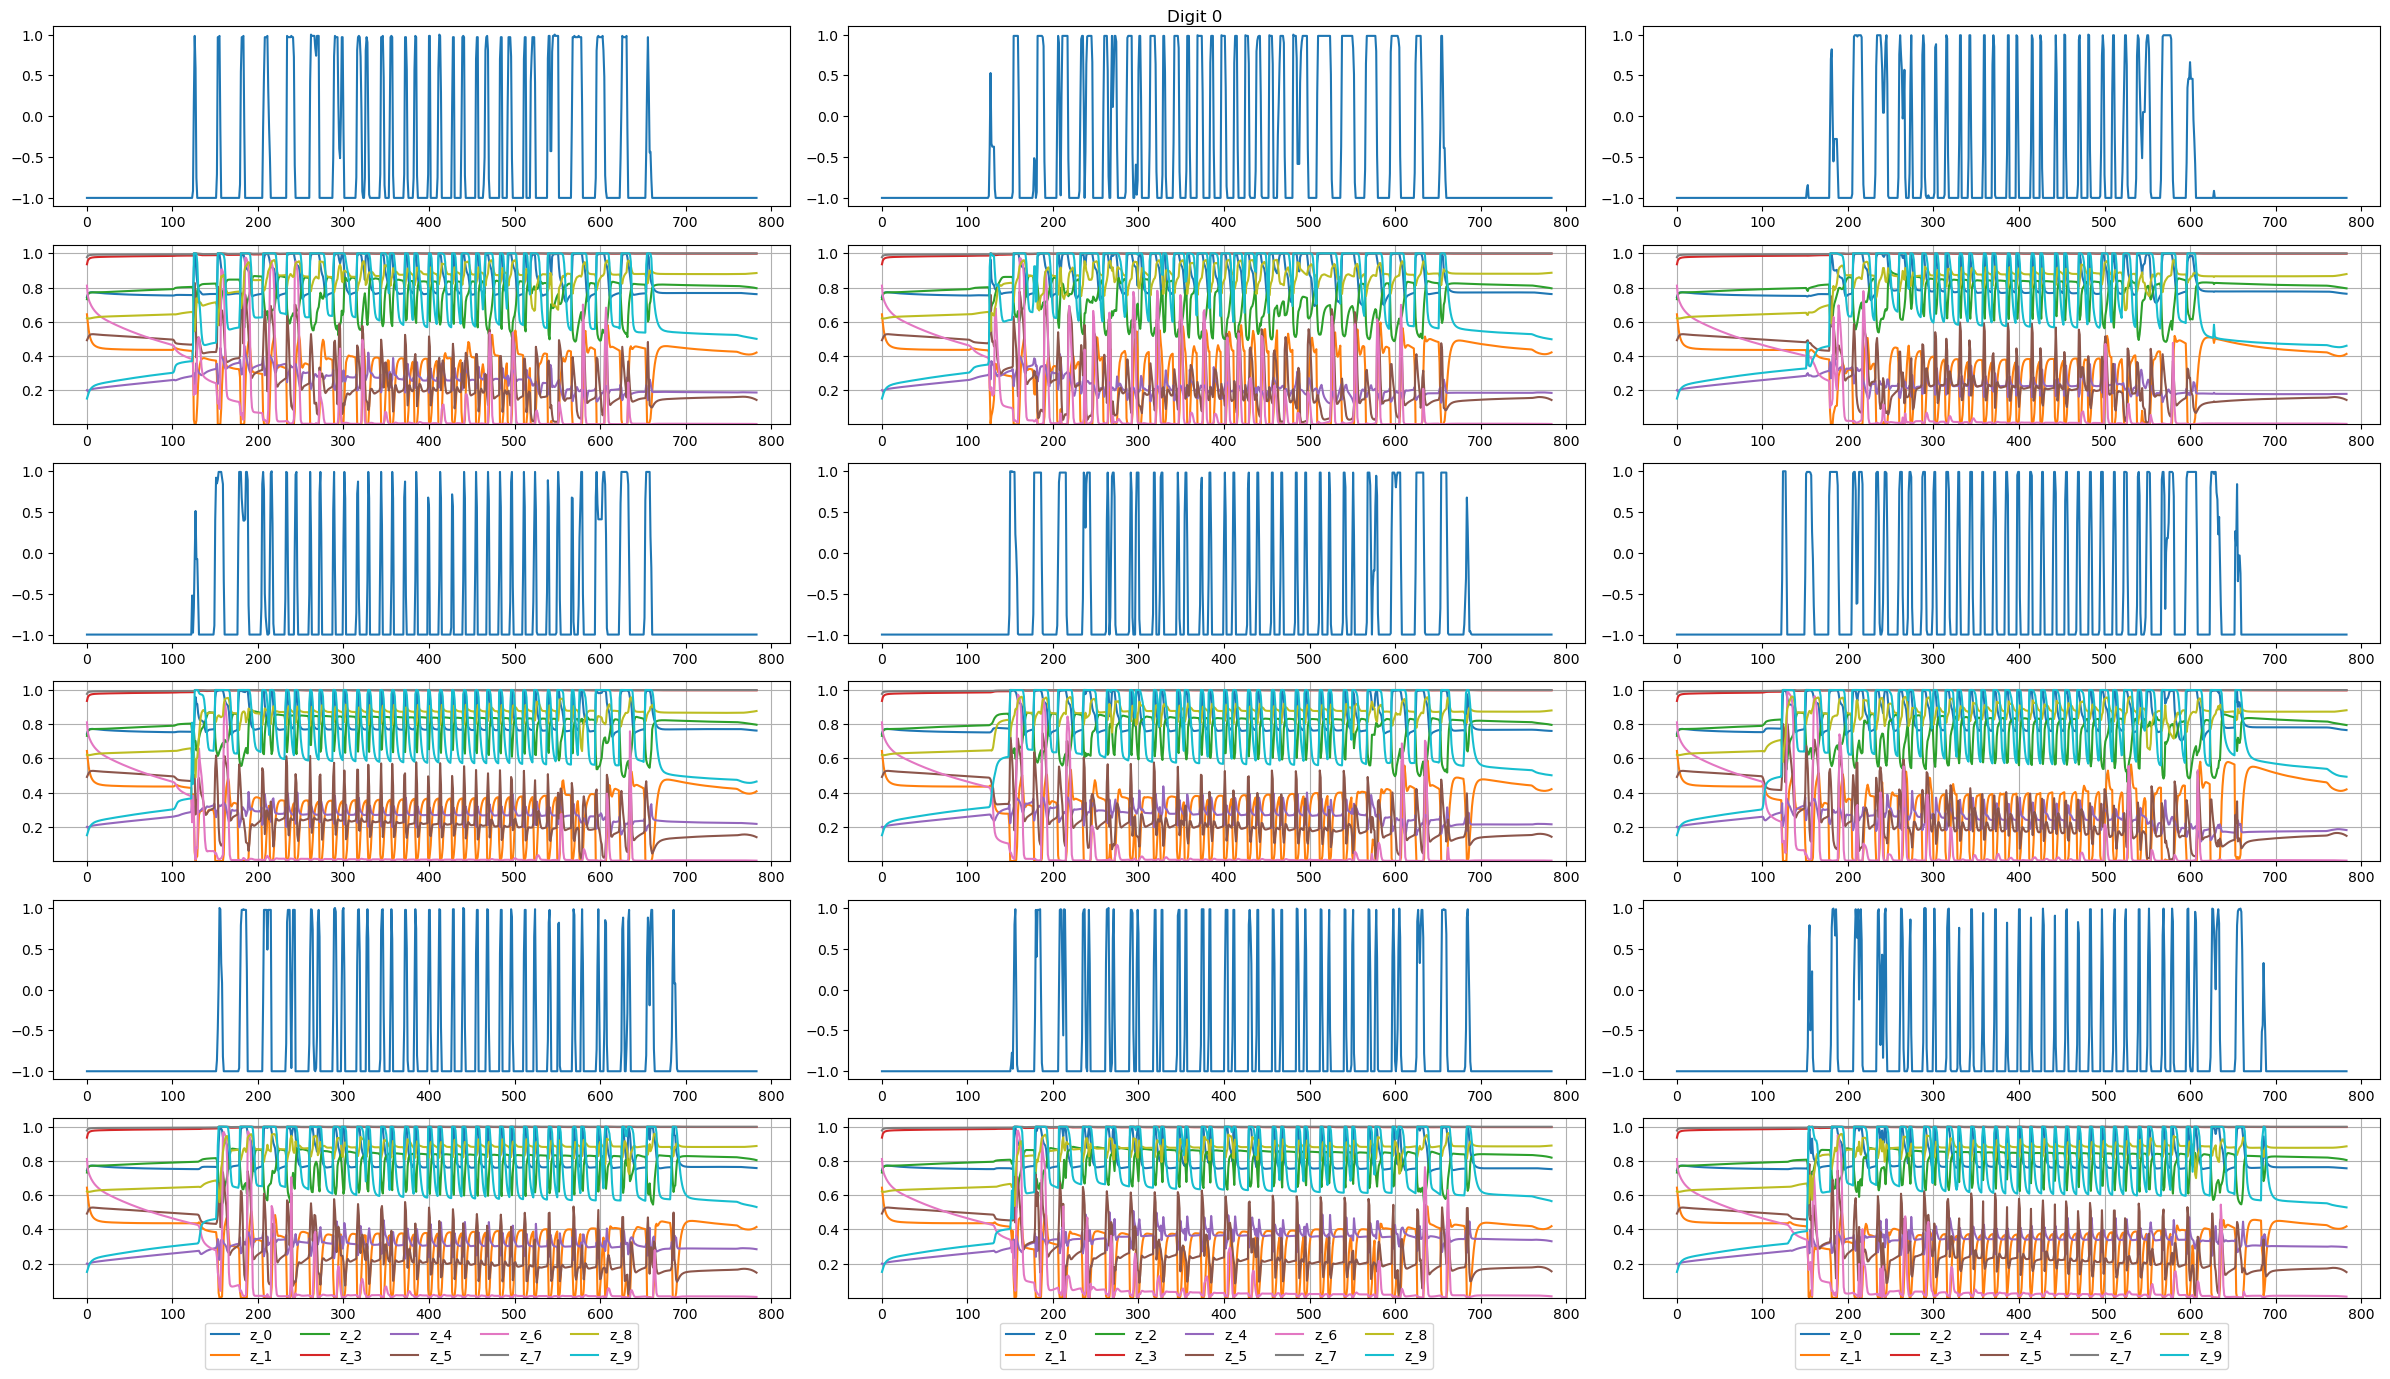

In [22]:
from utils import plot_digits
plot_digits(0, model, state.params, 'mingru_heinsen', 
            batch_x, batch_y, PLT_DIR, variable_to_plot='z',
            layer_to_plot=1, nb_components_to_plot=10)

(10, 784, 10)


/home/christian/LearningJAX/Flax/utils.py:523: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[-1, i].legend(ncol=legend_ncol, loc='upper center', bbox_to_anchor=(0.5, -0.1))


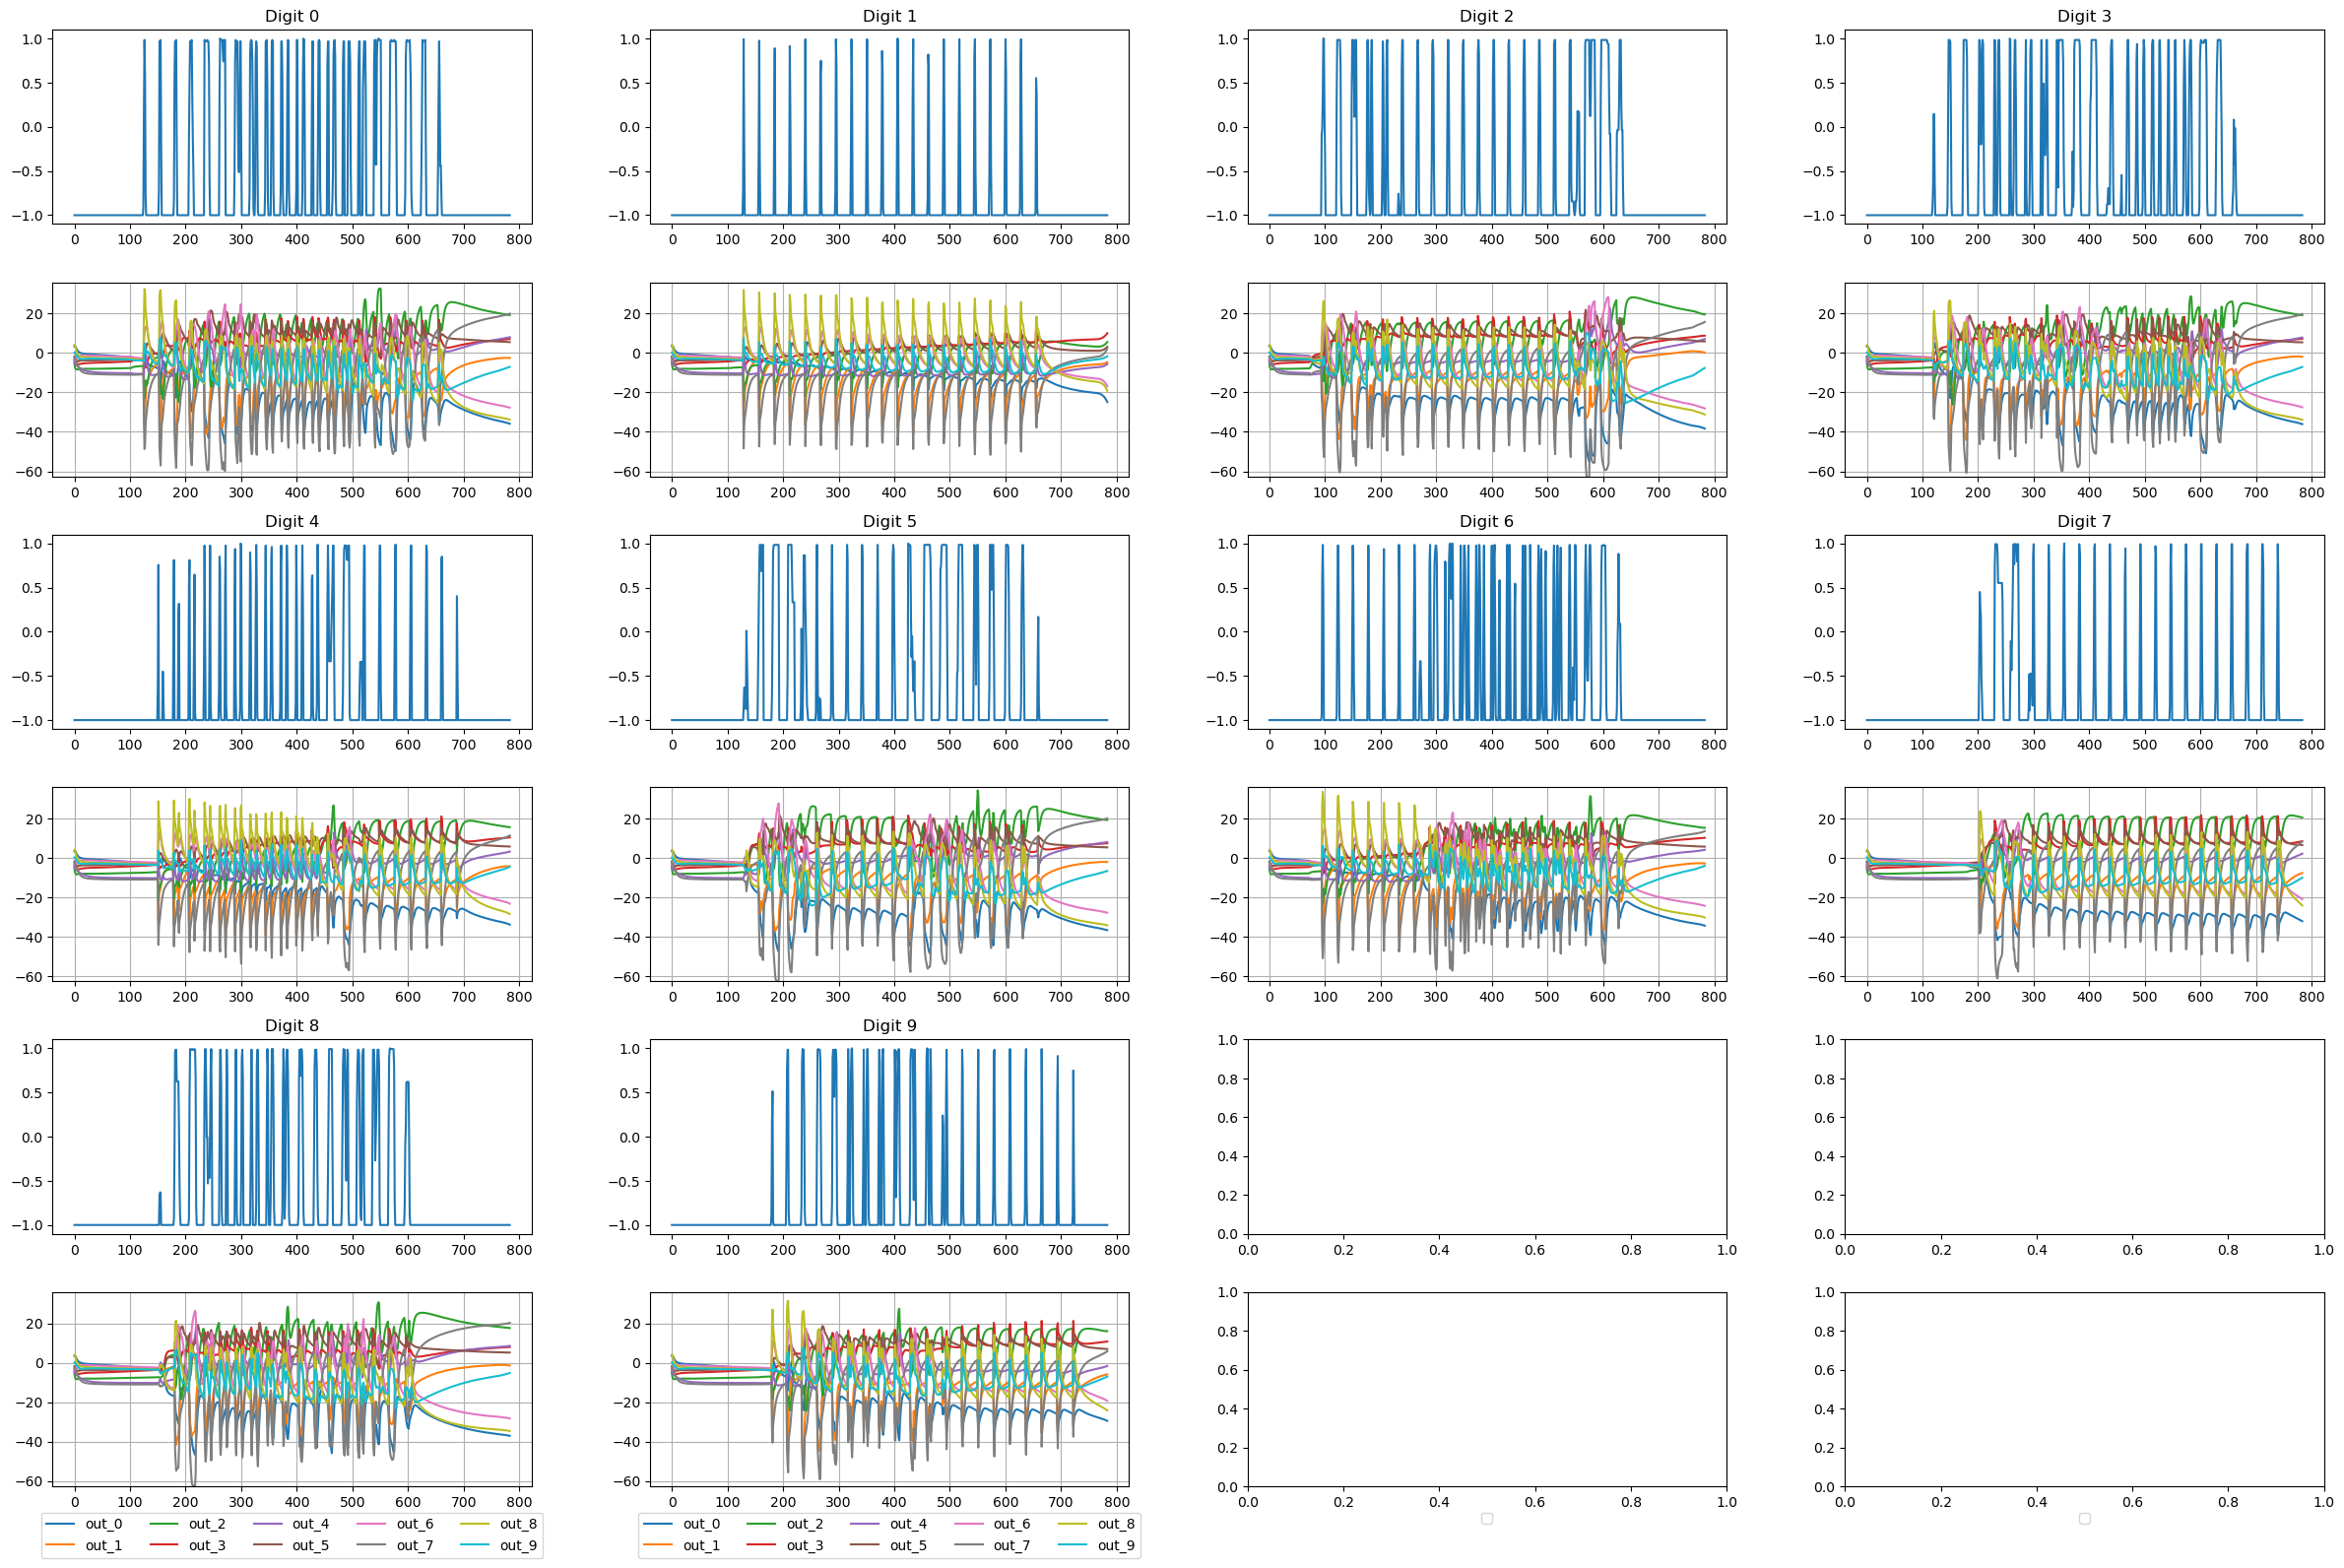

In [23]:
from utils import plot_all_digits
plot_all_digits(model, state.params, 'mingru_heinsen', batch_x, batch_y, plt_dir=PLT_DIR, 
                nb_components_to_plot=10, layer_to_plot=1, variable_to_plot='o')


In [ ]:
# how to write to a txt file
grads_hist = aux_dict_training[-1]['grads']
step_loss = aux_dict_training[-1]['loss']
with open('flax4b_minGRU_heinsen_grads.txt', 'w') as f:
    for i in range(len(aux_dict_training[-1]['grads'])):
        str_ = f'{jax.tree_util.tree_map(lambda x: round(float(jnp.max(jnp.abs(x))),2), grads_hist[i])}, {step_loss[i]}\n'
        f.write(str_)

In [ ]:
bad_state = aux_dict_training[-1]['state'][-2]
state_hist, out_hist = bad_state.apply_fn({'params': bad_state.params}, batch_x)
print(len(state_hist))
print(len(state_hist[0]))

2
3


2
3
(5, 784, 64)


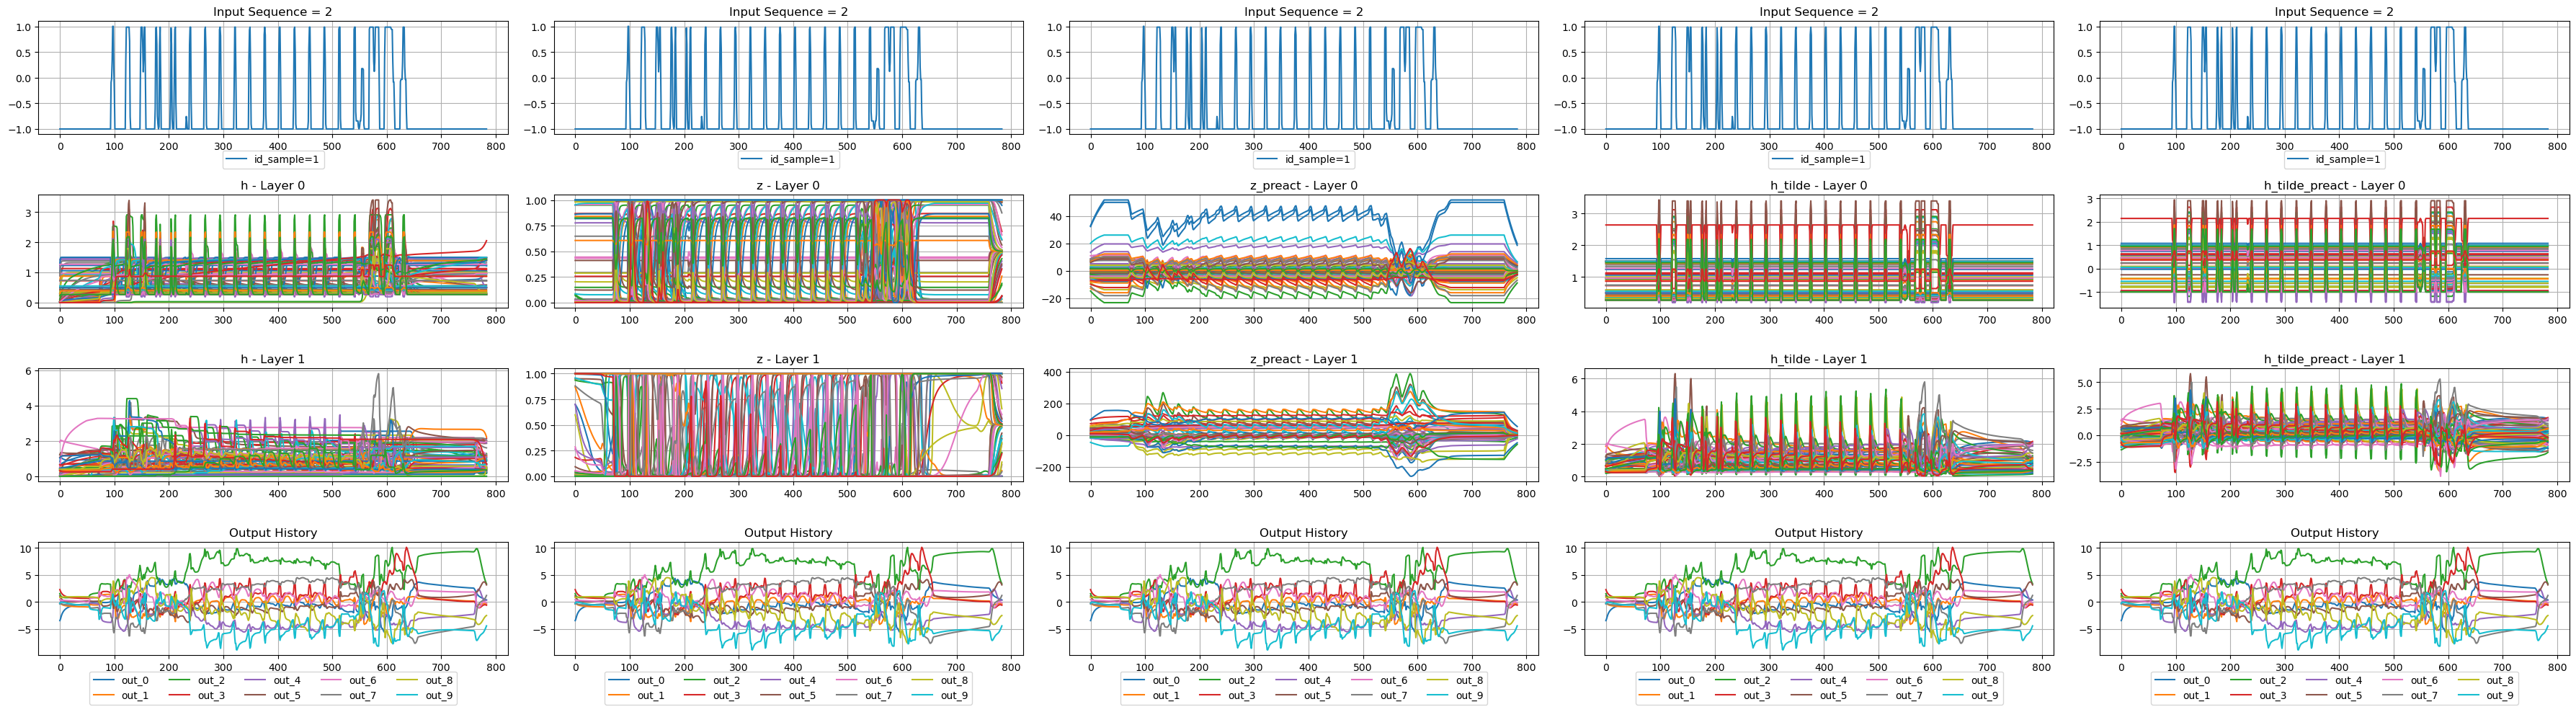

In [ ]:
plot_dynamics(model, bad_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=1, model_type='mingru_heinsen', variable_to_plot='all', nb_components_to_plot=HIDDEN_DIM, zoom=False)

print(len(aux))